# Customer Service Sentiment Analysis - EDA

This notebook starts with basic exploration of the train and test datasets.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option("display.max_columns", None) # to see all columns
pd.set_option("display.max_colwidth", 200)  # increase char limit

## 1. Load the data


In [21]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (970, 11)
Test shape: (30, 11)


## 2. Look at the datasets

In [24]:
display(train_df.head())
display(test_df.head())

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or email address during login,Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today?\n\nCustomer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG),..."
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked to ship the item,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.",Agent: Thank you for calling BrownBox customer support. My name is Alex. How may I assist you today?\n\nCustomer: Hi Alex. I recently received an email from BrownBox requesting me to ship back the...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to click the 'Cancel' button,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n\nCustomer: Hi Sarah, I am calling because I am unable to click the 'Cancel' button for my Ju..."
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to enter the correct verification code,Login Issues and Error Messages -> Error message regarding exceeded attempts to enter the correct verification code,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predefined steps ...","Customer: Hi, I am facing an issue while logging into my account. I am getting an error message saying that I have exceeded the number of attempts to enter the correct verification code.\n\nAgent:..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempted again,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for contacting BrownBox customer support. My name is Sarah. How can I assist you today?\n\nCustomer: Hi Sarah, I have an issue with my order. I received a BP monitor, but the deli..."


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Shopping,Pricing and Discounts,Discounts through exchange offers,Pricing and Discounts -> Discounts through exchange offers,negative,Appliances,Hand Blender,less,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n\nCustomer: Hi, Sarah. I am calling because I am interested in buying a hand blender, but the..."
1,Login and Account,Account Reactivation and Deactivation,Reactivating an inactive account,Account Reactivation and Deactivation -> Reactivating an inactive account,negative,Men/Women/Kids,Wrist Watch,medium,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How can I assist you today?\n\nCustomer: Hi Sarah, my name is John. I'm having trouble reactivating my account for a wrist..."
2,Cancellations and returns,Cash on Delivery (CoD) Refunds,Refund timelines for Cash on Delivery returns,Cash on Delivery (CoD) Refunds -> Refund timelines for Cash on Delivery returns,negative,Appliances,Induction Cooktop,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Jane. How may I assist you today?\n\nCustomer: Hi Jane, I am calling regarding the refund for my Induction Cooktop. I returned it..."
3,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as delivered but cannot be found,negative,Men/Women/Kids,Sunglas,high,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n\nCustomer: Hi Sarah, my name is John. I have a problem with my recent order. The package sho..."
4,Cancellations and returns,Pickup and Shipping,Reimbursement of courier charges for return,Pickup and Shipping -> Reimbursement of courier charges for return,negative,Electronics,Computer Monitor,medium,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: Thank you for calling BrownBox Customer Support. My name is Sarah. How may I assist you today?\n\nCustomer: Hi Sarah, I have an issue with a computer monitor that I received from your websi..."


In [25]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['issue_area', 'issue_category', 'issue_sub_category', 'issue_category_sub_category', 'customer_sentiment', 'product_category', 'product_sub_category', 'issue_complexity', 'agent_experience_level', 'agent_experience_level_desc', 'conversation']
Test columns: ['issue_area', 'issue_category', 'issue_sub_category', 'issue_category_sub_category', 'customer_sentiment', 'product_category', 'product_sub_category', 'issue_complexity', 'agent_experience_level', 'agent_experience_level_desc', 'conversation']


* issue_area: broad topic of the customer problem, like login, order, return
* issue_category: more specific group inside the issue area
* issue_sub_category: even more detailed issue type
* issue_category_sub_category: combined version of category and sub-category
* customer_sentiment: target label, this is what you want to predict
* product_category: broad product group
* product_sub_category: detailed product type
* issue_complexity: difficulty level of the issue
* agent_experience_level: support agent seniority
* agent_experience_level_desc: text description of the agent level
* conversation: full customer-agent dialogue, your main text feature

## 3. Data types / # of rows

In [8]:
print("TRAIN INFO")
train_df.info()

print("\nTEST INFO")
test_df.info()

TRAIN INFO
<class 'pandas.DataFrame'>
RangeIndex: 970 entries, 0 to 969
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   issue_area                   970 non-null    str  
 1   issue_category               970 non-null    str  
 2   issue_sub_category           970 non-null    str  
 3   issue_category_sub_category  970 non-null    str  
 4   customer_sentiment           970 non-null    str  
 5   product_category             970 non-null    str  
 6   product_sub_category         970 non-null    str  
 7   issue_complexity             970 non-null    str  
 8   agent_experience_level       970 non-null    str  
 9   agent_experience_level_desc  970 non-null    str  
 10  conversation                 970 non-null    str  
dtypes: str(11)
memory usage: 83.5 KB

TEST INFO
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column               

## 4. Missing values

In [26]:
train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

print("Train missing values:")
display(train_missing[train_missing > 0])

print("Test missing values:")
display(test_missing[test_missing > 0])

Train missing values:


Series([], dtype: int64)

Test missing values:


Series([], dtype: int64)

## 5. Duplicate rows

In [10]:
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [27]:
# Count duplicate conversation values
train_conv_dups = train_df["conversation"].duplicated().sum()
test_conv_dups = test_df["conversation"].duplicated().sum()

print("Train conversation duplicates:", train_conv_dups)
print("Test conversation duplicates:", test_conv_dups)

# Print duplicated conversations (including all repeated rows)
train_dup_rows = train_df[train_df["conversation"].duplicated(keep=False)].sort_values("conversation")
test_dup_rows = test_df[test_df["conversation"].duplicated(keep=False)].sort_values("conversation")

print("\nDuplicated conversations in train:")
print(train_dup_rows[["conversation"]])

print("\nDuplicated conversations in test:")
print(test_dup_rows[["conversation"]])


Train conversation duplicates: 2
Test conversation duplicates: 0

Duplicated conversations in train:
                                       conversation
191  Agent: You're welcome, Jane. Have a great day!
286  Agent: You're welcome, Jane. Have a great day!
750  Agent: You're welcome, Jane. Have a great day!

Duplicated conversations in test:
Empty DataFrame
Columns: [conversation]
Index: []


In [29]:
duplication = "Agent: You're welcome, Jane. Have a great day!"

display(train_df[train_df["conversation"] == duplication])
display(test_df[test_df["conversation"] == duplication])

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
191,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as delivered but cannot be found,negative,Men/Women/Kids,Shorts,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: You're welcome, Jane. Have a great day!"
286,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as delivered but cannot be found,negative,Men/Women/Kids,T-Shirt,less,inexperienced,"may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predefined steps ...","Agent: You're welcome, Jane. Have a great day!"
750,Order,Order Delivery Issues,Order approved but not shipped,Order Delivery Issues -> Order approved but not shipped,negative,Appliances,Sandwich Maker,less,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: You're welcome, Jane. Have a great day!"


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation


They should be cleaned. There is no negative sentiment and duplicated!

## 6. Quick summary statistics

In [11]:
display(train_df.describe(include="all").T)
display(test_df.describe(include="all").T)

,count,unique,top,freq
issue_area,970,6,Cancellations and returns,277
issue_category,970,40,Return and Exchange,92
issue_sub_category,970,109,Verification requirement for mobile number or email address during login,17
issue_category_sub_category,970,109,Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login,17
customer_sentiment,970,3,neutral,542
product_category,970,3,Appliances,454
product_sub_category,970,50,Water Purifier,26
issue_complexity,970,3,less,472
agent_experience_level,970,3,junior,490
agent_experience_level_desc,970,3,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.",490


,count,unique,top,freq
issue_area,30,6,Order,12
issue_category,30,16,Order Confirmation and Status,6
issue_sub_category,30,22,Confirming order status,5
issue_category_sub_category,30,22,Order Confirmation and Status -> Confirming order status,5
customer_sentiment,30,3,negative,10
product_category,30,3,Appliances,11
product_sub_category,30,21,Vacuum Cleaner,3
issue_complexity,30,3,less,16
agent_experience_level,30,3,junior,17
agent_experience_level_desc,30,3,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.",17


In train dataset, we should analyze:
- **issue_area:** There are 6 unique values, which can help us understand differences in word count and sentiment distribution across these areas.
- **issue_category:** There are 40 unique values, it is relatively high # of category but nevetheless which can help us understand differences in word count and sentiment distribution across these categories.
- **issue_complexity:** There are 3 unique values, which can help us analyze differences in word count and sentiment distribution across different complexity levels. There may also be a relationship between issue complexity and sentiment.
- **product_category:** There are 3 unique values, which can help us analyze differences in word count and sentiment distribution across different product categories.
- **product_sub_category:** There are 21 unique values, which can help us analyze differences in word count and sentiment distribution across different product sub categories. It has more detailed product category values.
- **agent_experience_level:** here are 3 unique values, which can help us analyze differences in word count and sentiment distribution across different agent experience level.

So, the other columns seem to have # of unique values and they can not be helpful for now. But maybe we can use them to test model later.

- issue_sub_category --> too detailed, instead of this issue category will give us more meaningful discrimination.
- issue_category_sub_category --> no need for this column bc it is --> issue category + issue sub category
- agent_experience_level_desc --> includes only description for experience level, no need to analyze


## 7. Sentiment label distribution

In [12]:
train_df["customer_sentiment"].value_counts()

customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64

In [13]:
(train_df["customer_sentiment"].value_counts(normalize=True) * 100).round(2)

customer_sentiment
neutral     55.88
negative    42.37
positive     1.75
Name: proportion, dtype: float64

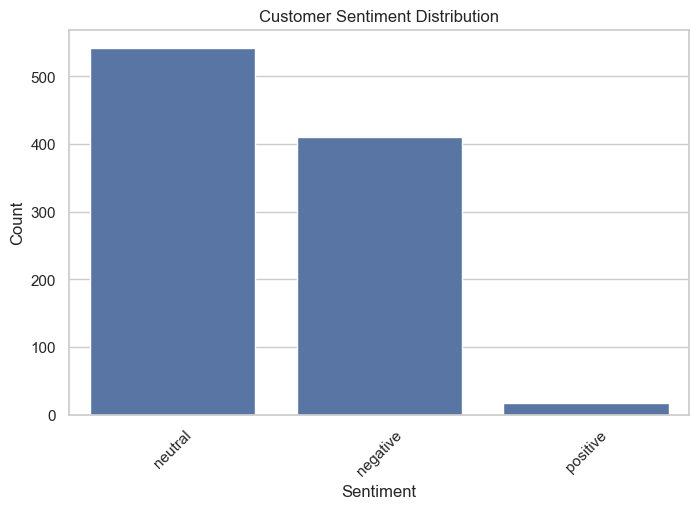

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=train_df,
    x="customer_sentiment",
    order=train_df["customer_sentiment"].value_counts().index
)
plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Unfortunately, the sentiment distribution in the training set is not uniform, it is an imbalanced dataset. There are significantly fewer positive samples compared to neutral and negative ones.

## 8. Conversation length features

In [15]:
train_df["char_count"] = train_df["conversation"].astype(str).apply(len)
train_df["word_count"] = train_df["conversation"].astype(str).apply(lambda x: len(x.split()))

In [16]:
display(train_df[["char_count", "word_count"]].describe())

,char_count,word_count
count,970.000000,970.000000
mean,2129.284536,370.860825
std,564.751035,98.267606
min,46.000000,8.000000
25%,1760.250000,306.000000
50%,2058.500000,357.000000
75%,2430.000000,424.000000
max,5708.000000,992.000000


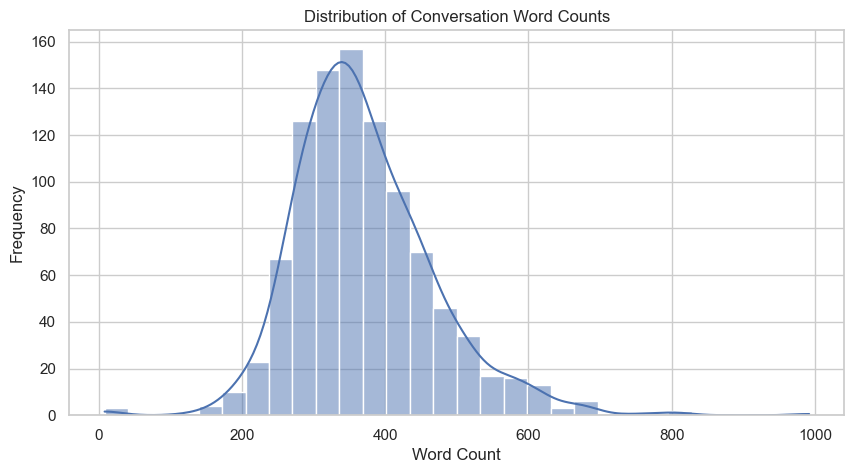

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df["word_count"], bins=30, kde=True)
plt.title("Distribution of Conversation Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

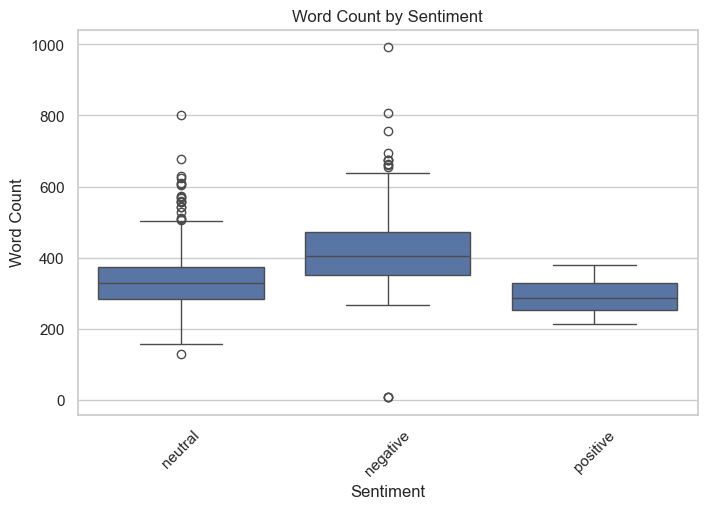

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="customer_sentiment", y="word_count")
plt.title("Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.xticks(rotation=45)
plt.show()

## 9. Distribution of conversation word counts for each sentiment

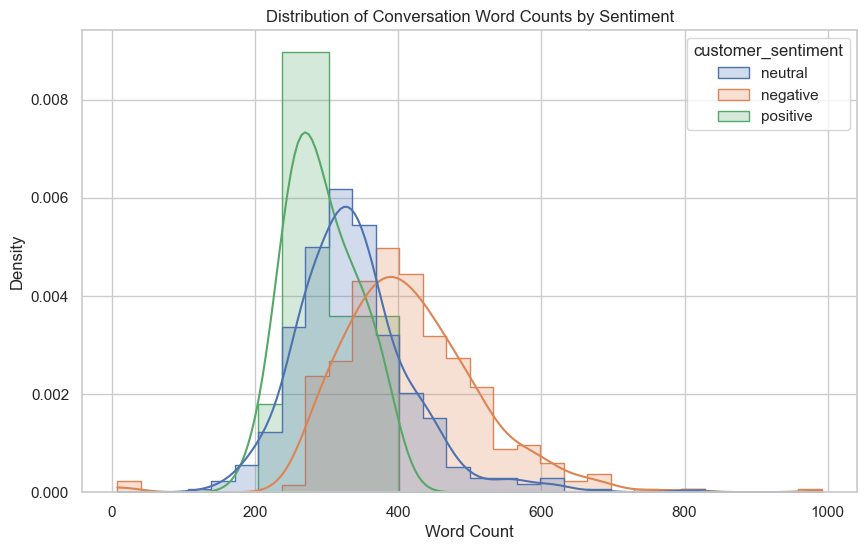

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=train_df,
    x="word_count",
    hue="customer_sentiment",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Distribution of Conversation Word Counts by Sentiment")
plt.xlabel("Word Count")
plt.ylabel("Density")
plt.show()

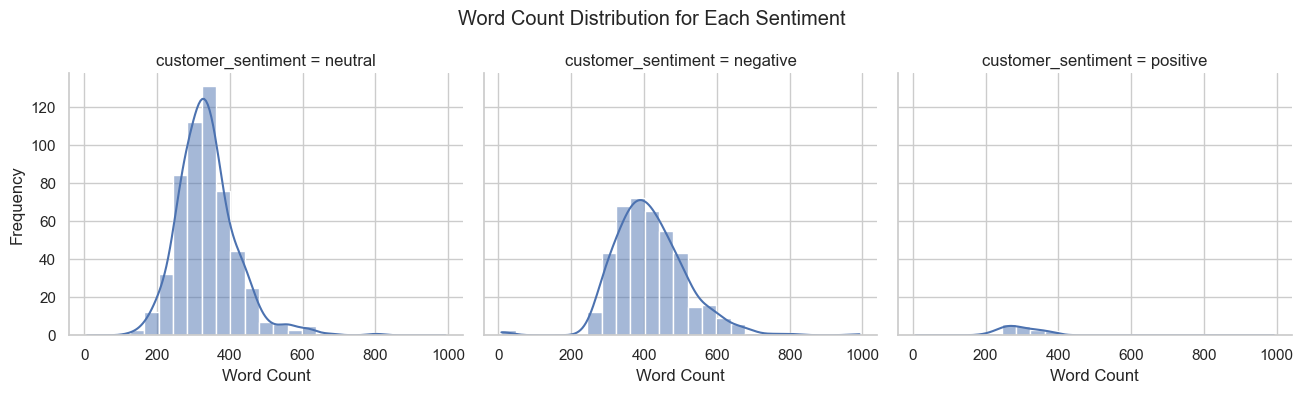

In [20]:
g = sns.displot(
    data=train_df,
    x="word_count",
    col="customer_sentiment",
    kde=True,
    bins=25,
    height=4,
    aspect=1.1
)
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Word Count Distribution for Each Sentiment")
g.set_axis_labels("Word Count", "Frequency")

Negative conversations tend to have a higher word count compared to neutral and positive sentiments. There are very few positive samples (17), and they have the lowest average word count among the sentiment categories.

## 10. Sentiment by issue area

In [30]:
issue_area_sentiment_counts = pd.crosstab(train_df["issue_area"], train_df["customer_sentiment"])
display(issue_area_sentiment_counts)

customer_sentiment,negative,neutral,positive
issue_area,,,
Cancellations and returns,136,141,0
Login and Account,28,121,0
Order,156,85,17
Shipping,37,33,0
Shopping,36,77,0
Warranty,18,85,0


customer_sentiment,negative,neutral,positive
issue_area,,,
Cancellations and returns,49.1,50.9,0.0
Login and Account,18.8,81.2,0.0
Order,60.5,32.9,6.6
Shipping,52.9,47.1,0.0
Shopping,31.9,68.1,0.0
Warranty,17.5,82.5,0.0


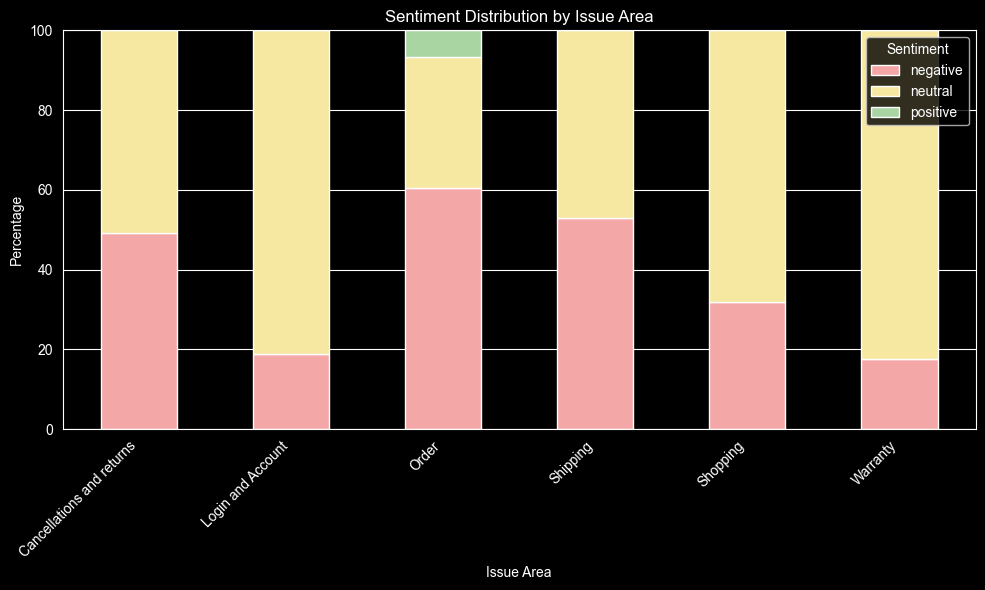

In [4]:
# First see the percentages
issue_area_sentiment_pct = pd.crosstab(
    train_df["issue_area"],
    train_df["customer_sentiment"],
    normalize="index"
).round(3) * 100

display(issue_area_sentiment_pct)

# Then see them with stacked graph
sentiment_colors = {
    "negative": "#f4a7a7",  # soft red
    "neutral": "#f6e7a1",   # soft yellow
    "positive": "#a8d5a2",  # soft green
}

issue_area_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[sentiment_colors[col] for col in issue_area_sentiment_pct.columns]
)

plt.title("Sentiment Distribution by Issue Area")
plt.xlabel("Issue Area")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


- "Order" has the highest number of negative sentiments, making it the most problematic category. At the same time, all positive sentiments are also related to orders. Because of this, identifying positive sentiment for other issue categories may be more challenging for the model.

- "Login and Account" issues most often end with neutral sentiment.

- Overall, "Order" and "Cancellations and Returns" appear to be the top areas that should be prioritized for improvement.

So: There are noticeable percentage differences across categories, which suggests that the issue area may contain valuable information for sentiment classification.

## 12. Sentiment by top issue categories

Let's take top 10, bc there are 40 different issue categories


In [35]:
top_issue_categories = train_df["issue_category"].value_counts().head(10).index
top_issue_df = train_df[train_df["issue_category"].isin(top_issue_categories)].copy()

issue_category_sentiment_counts = pd.crosstab(
    top_issue_df["issue_category"],
    top_issue_df["customer_sentiment"]
)
display(issue_category_sentiment_counts.loc[top_issue_categories])

customer_sentiment,negative,neutral,positive
issue_category,,,
Return and Exchange,53,39,0
Order Delivery Issues,90,0,0
Pickup and Shipping,42,23,0
Mobile Number and Email Verification,15,44,0
Replacement and Return Process,11,46,0
Returns and Refunds,29,8,0
Invoice and Payment,19,17,0
Pricing and Discounts,16,18,0
Lost or Missing Warranty Card,10,21,0


In [36]:
issue_category_sentiment_pct = pd.crosstab(
    top_issue_df["issue_category"],
    top_issue_df["customer_sentiment"],
    normalize="index"
).round(3) * 100
issue_category_sentiment_pct = issue_category_sentiment_pct.loc[top_issue_categories]
display(issue_category_sentiment_pct)

customer_sentiment,negative,neutral,positive
issue_category,,,
Return and Exchange,57.6,42.4,0.0
Order Delivery Issues,100.0,0.0,0.0
Pickup and Shipping,64.6,35.4,0.0
Mobile Number and Email Verification,25.4,74.6,0.0
Replacement and Return Process,19.3,80.7,0.0
Returns and Refunds,78.4,21.6,0.0
Invoice and Payment,52.8,47.2,0.0
Pricing and Discounts,47.1,52.9,0.0
Lost or Missing Warranty Card,32.3,67.7,0.0


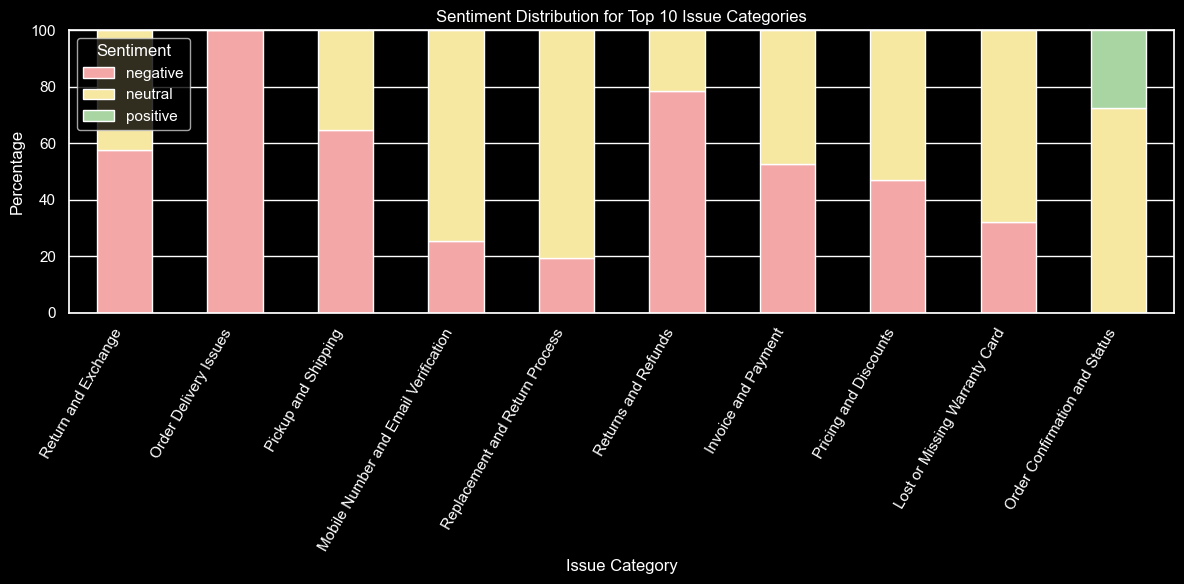

In [38]:
issue_category_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[sentiment_colors[col] for col in issue_category_sentiment_pct.columns] # use prev colors
)

plt.title("Sentiment Distribution for Top 10 Issue Categories")
plt.xlabel("Issue Category")
plt.ylabel("Percentage")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

The most important finding is that all “Order Delivery Issue” cases are marked as negative.
There are noticeable percentage differences across categories, which suggests that the issue category may contain valuable information for sentiment classification.

Let’s briefly examine which categories belong to which areas.

In [10]:
issue_area_category_map = (
    train_df[["issue_area", "issue_category"]]
    .drop_duplicates()
    .sort_values(["issue_area", "issue_category"])
    .reset_index(drop=True)
)
display(issue_area_category_map)

,issue_area,issue_category
0,Cancellations and returns,Cash on Delivery (CoD) Refunds
1,Cancellations and returns,Order Cancellation
2,Cancellations and returns,Pickup and Shipping
3,Cancellations and returns,Replacement and Return Process
4,Cancellations and returns,Return Checks and Fees
5,Cancellations and returns,Return and Exchange
6,Login and Account,Account Reactivation and Deactivation
7,Login and Account,Adding and Changing Account Information
8,Login and Account,Login Issues and Error Messages
9,Login and Account,Login Methods


## 13. Sentiment by issue complexity

In [6]:
issue_complexity_sentiment_pct = pd.crosstab(
    train_df["issue_complexity"],
    train_df["customer_sentiment"],
    normalize="index"
).round(3) * 100
display(issue_complexity_sentiment_pct)

customer_sentiment,negative,neutral,positive
issue_complexity,,,
high,47.6,48.8,3.7
less,41.7,56.8,1.5
medium,42.1,56.2,1.7


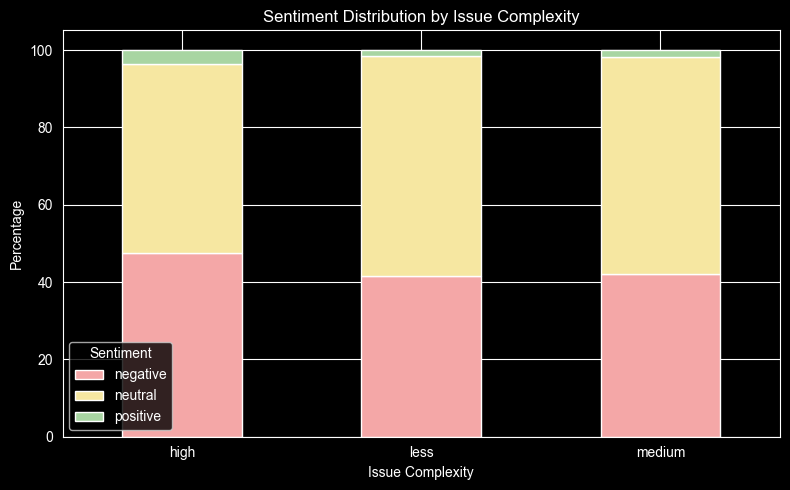

In [7]:
issue_complexity_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[sentiment_colors[col] for col in issue_complexity_sentiment_pct.columns]  # use prev colors
)

plt.title("Sentiment Distribution by Issue Complexity")
plt.xlabel("Issue Complexity")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

Unfortunately, there is no obvious correlation between issue complexity and sentiments :( We can say that, where the complexity is less or medium, there are more neutral sentiments but, at the high complexity, there is no obvious diff between sentiment distribution.

## 14. Sentiment by product category and product sub category

### Product Category

In [8]:
product_category_sentiment_pct = pd.crosstab(
    train_df["product_category"],
    train_df["customer_sentiment"],
    normalize="index"
).round(3) * 100
display(product_category_sentiment_pct)

customer_sentiment,negative,neutral,positive
product_category,,,
Appliances,41.9,56.2,2.0
Electronics,41.6,58.0,0.3
Men/Women/Kids,44.4,52.5,3.1


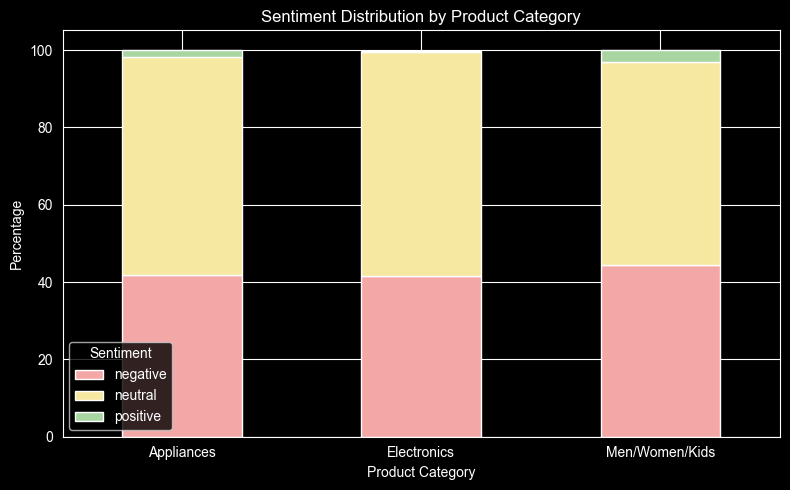

In [9]:
product_category_sentiment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[sentiment_colors[col] for col in product_category_sentiment_pct.columns]  # use prev colors
)

plt.title("Sentiment Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

Unfortunately, there is no obvious correlation between issue product category and sentiments :(

### Product Sub Category

In [49]:
product_sub_category_sentiment_pct = pd.crosstab(
    train_df["product_sub_category"],
    train_df["customer_sentiment"],
    normalize="index"
).round(3) * 100
display(product_sub_category_sentiment_pct)

# TOO MUCH TO VISUALIZE IT!!!!!!
# product_sub_category_sentiment_pct.plot(
#     kind="bar",
#     stacked=True,
#     figsize=(8, 5),
#     color=[sentiment_colors[col] for col in product_sub_category_sentiment_pct.columns]  # use prev colors
# )
#
# plt.title("Sentiment Distribution by Product SUB Category")
# plt.xlabel("Product SUB Category")
# plt.ylabel("Percentage")
# plt.xticks(rotation=0)
# plt.legend(title="Sentiment")
# plt.tight_layout()
# plt.show()

customer_sentiment,negative,neutral,positive
product_sub_category,,,
Air Conditioner,45.0,55.0,0.0
Air Cooler,38.1,61.9,0.0
Baby Food,66.7,33.3,0.0
Backpack,64.3,35.7,0.0
Bp Monitor,38.5,61.5,0.0
Ceiling Fan,57.1,42.9,0.0
Coffee Maker,38.9,61.1,0.0
Computer Monitor,45.8,54.2,0.0
DSLR Camera,40.0,60.0,0.0


There are subgroups with high neutral sentiment percentages (around 70%–80%), including:
- Laptop
- Water Geyser
- Headphone
- Food Processor
- Shoes
- Tablet
- Inverter

There are also subgroups with moderate to high negative sentiment percentages (around 55%–66%), including:
- Vacuum Cleaner
- Ceiling Fan
- Backpack
- Baby Food

# 15. See issue complexity and agent experience relations

Does customer sentiment change depending on whether the conversation was handled by an inexperienced, junior, or experienced agent?

In [23]:
complexity_pct = pd.crosstab(
    train_df["issue_complexity"],
    train_df["customer_sentiment"],
    normalize="index"
).round(3) * 100

agent_pct = pd.crosstab(
    train_df["agent_experience_level"],
    train_df["customer_sentiment"],
    normalize="index"
).round(3) * 100


complexity_agent_pct = pd.crosstab(
    train_df["agent_experience_level"],
    train_df["issue_complexity"],
    normalize="index"
).round(3) * 100

display(complexity_pct)
display(agent_pct)
display(complexity_agent_pct)

customer_sentiment,negative,neutral,positive
issue_complexity,,,
high,47.6,48.8,3.7
less,41.7,56.8,1.5
medium,42.1,56.2,1.7


customer_sentiment,negative,neutral,positive
agent_experience_level,,,
experienced,43.4,55.5,1.2
inexperienced,33.3,66.0,0.7
junior,44.3,53.3,2.4


issue_complexity,high,less,medium
agent_experience_level,,,
experienced,8.8,49.3,41.9
inexperienced,6.4,47.5,46.1
junior,8.8,48.6,42.7


* Again this shows that issue complexity does not create a strong separation in sentiment.
* Agent experience level seems only weakly related to sentiment.
* For agent_experience_level vs issue_complexity, the distributions are also very similar. All three agent groups mostly handle less and medium complexity issues, while high complexity cases are relatively rare for everyone. This means issue complexity is not strongly differentiated by agent level in this dataset.

## 15. Most frequent words in conversations by sentiment

This section explores the most common words in conversations for each sentiment label.
The text is cleaned by lowercasing, removing punctuation, and filtering common stopwords and generic customer-service words.

In [24]:
import re
from collections import Counter

In [34]:
custom_stopwords = {
    "the", "a", "an", "and", "or", "but", "if", "to", "of", "in", "on", "for", "with", "at", "by",
    "is", "are", "was", "were", "be", "been", "being", "am",
    "i", "you", "he", "she", "it", "we", "they", "me", "my", "your", "our", "their", "us", "them",
    "this", "that", "these", "those", "there", "here", "as", "from", "into", "about", "can", "could",
    "would", "should", "will", "just", "have", "has", "had", "do", "does", "did", "so", "not",
    "hi", "hello", "thanks", "thank", "please", "help", "assist", "today", "name", "calling", "contacting",
    "agent", "customer", "support", "brownbox", "may", "know", "let", "like", "okay", "ok", "sure",
    "one", "get", "got", "also", "im", "ive", "youre", "thats", "dont", "cant", "email", "order", "number",
    "address", "john", "sarah", "any", "goodbye", "emily", "welcome","account"
}

I removed several frequently repeated words (e.g., “email,” “number”) because they do not provide meaningful insights for the analysis.

In [35]:
def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in custom_stopwords and len(word) > 2]
    return tokens

In [36]:
def get_top_words_by_sentiment(df, sentiment, text_col="conversation", top_n=15):
    sentiment_text = df.loc[df["customer_sentiment"] == sentiment, text_col]
    all_words = []
    for text in sentiment_text:
        all_words.extend(clean_and_tokenize(text))
    return pd.DataFrame(Counter(all_words).most_common(top_n), columns=["word", "frequency"])


In [37]:
negative_top_words = get_top_words_by_sentiment(train_df, "negative")
neutral_top_words = get_top_words_by_sentiment(train_df, "neutral")
positive_top_words = get_top_words_by_sentiment(train_df, "positive")

display(negative_top_words)
display(neutral_top_words)
display(positive_top_words)

,word,frequency
0,sorry,962
1,check,876
2,hold,806
3,refund,751
4,return,745
5,delivery,717
6,understand,700
7,see,658
8,however,615
9,hear,568


,word,frequency
0,return,898
1,great,806
2,check,799
3,warranty,752
4,how,739
5,process,693
6,see,686
7,yes,663
8,day,638
9,all,627


,word,frequency
0,product,33
1,great,32
2,yes,30
3,check,29
4,hold,29
5,status,26
6,return,23
7,all,22
8,seller,22
9,day,20


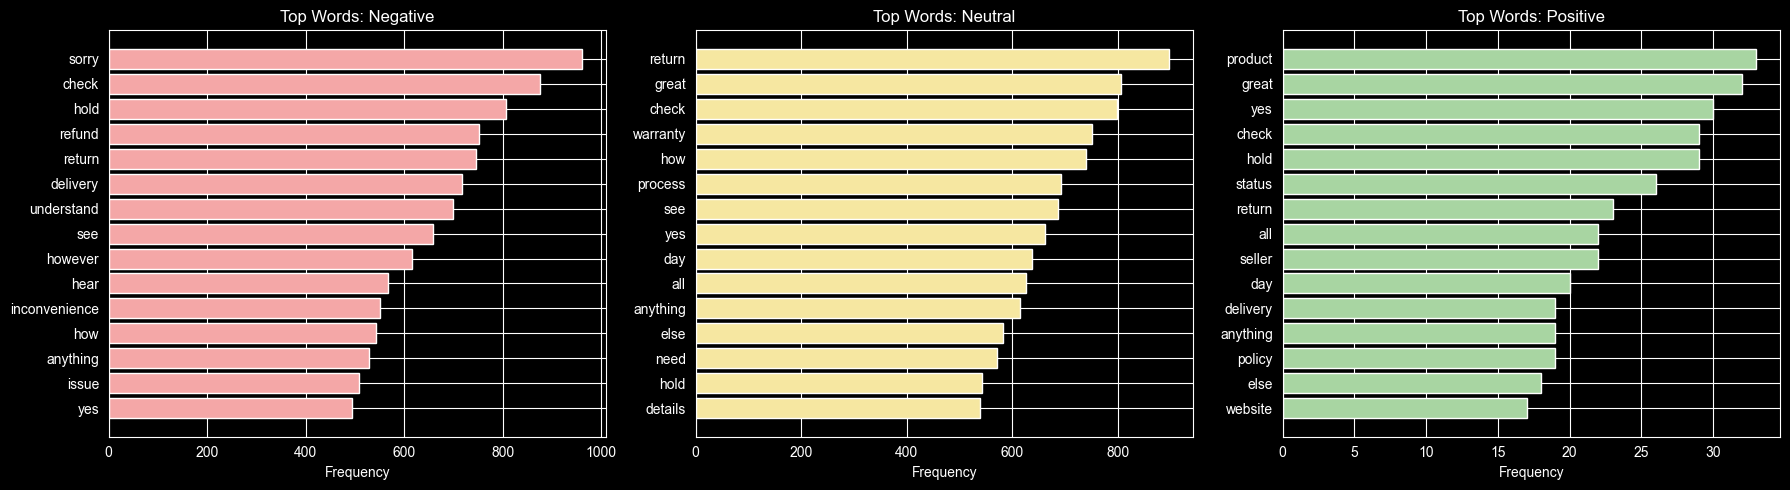

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sentiment_word_tables = {
    "negative": negative_top_words,
    "neutral": neutral_top_words,
    "positive": positive_top_words,
}

plot_colors = {
    "negative": "#f4a7a7",  # soft red
    "neutral": "#f6e7a1",   # soft yellow
    "positive": "#a8d5a2",  # soft green
}


for ax, (sentiment, word_df) in zip(axes, sentiment_word_tables.items()):
    ax.barh(word_df["word"], word_df["frequency"], color=plot_colors[sentiment])
    ax.set_title(f"Top Words: {sentiment.capitalize()}")
    ax.set_xlabel("Frequency")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

- The word-frequency analysis shows meaningful differences across sentiment classes.
- Negative conversations are associated with complaint-related and apology-related words such as refund, return, and sorry.
- Neutral conversations are more focused on process and clarification terms such as warranty, process, and details.
- Positive conversations contain more satisfaction-oriented words such as great and yes, BUT the positive class is very small. So its top words may be less stable than the other two classes.

## 16. Final checks for EDA

Summarize
* class balance
* train-test consistency
* duplicates
* common bigrams
* check sample conversations before going forward, it is really important to understand the dataset!!!

### Class imbalance summary

In [39]:
class_summary = pd.DataFrame({
    "count": train_df["customer_sentiment"].value_counts(),
    "percentage": (train_df["customer_sentiment"].value_counts(normalize=True) * 100).round(2)
})
display(class_summary)

,count,percentage
customer_sentiment,,
neutral,542,55.88
negative,411,42.37
positive,17,1.75


As indicated in the previous sections, dataset is imbalanced, especially positive sentiments are really low.

### Train vs test categorical distribution

In [45]:
compare_cols = ["customer_sentiment","issue_area", "product_category", "issue_complexity", "agent_experience_level"]

for col in compare_cols:
    print(f"\n===== {col} =====")
    train_dist = train_df[col].value_counts(normalize=True).sort_index().rename("train_pct") * 100
    test_dist = test_df[col].value_counts(normalize=True).sort_index().rename("test_pct") * 100
    comparison = pd.concat([train_dist, test_dist], axis=1).fillna(0).round(2)
    display(comparison)


===== customer_sentiment =====


,train_pct,test_pct
customer_sentiment,,
negative,42.37,33.33
neutral,55.88,33.33
positive,1.75,33.33



===== issue_area =====


,train_pct,test_pct
issue_area,,
Cancellations and returns,28.56,30.00
Login and Account,15.36,6.67
Order,26.60,40.00
Shipping,7.22,6.67
Shopping,11.65,10.00
Warranty,10.62,6.67



===== product_category =====


,train_pct,test_pct
product_category,,
Appliances,46.80,36.67
Electronics,30.21,33.33
Men/Women/Kids,22.99,30.00



===== issue_complexity =====


,train_pct,test_pct
issue_complexity,,
high,8.45,13.33
less,48.66,53.33
medium,42.89,33.33



===== agent_experience_level =====


,train_pct,test_pct
agent_experience_level,,
experienced,34.95,30.00
inexperienced,14.54,13.33
junior,50.52,56.67


There is no obvious inconsistency between train and test distribution by important columns.

### Duplicate conversation summary

In [41]:
print("Exact duplicate rows:", train_df.duplicated().sum())
print("Duplicate conversation texts:", train_df["conversation"].duplicated().sum())

Exact duplicate rows: 0
Duplicate conversation texts: 2


2 duplications exist, no big problem.

### Top bigrams by sentiment

In [43]:
def get_top_bigrams_by_sentiment(df, sentiment, text_col="conversation", top_n=15):
    sentiment_text = df.loc[df["customer_sentiment"] == sentiment, text_col]
    bigrams = []
    for text in sentiment_text:
        tokens = clean_and_tokenize(text) # Remove again common stopwords and generic customer-service words that listed above
        bigrams.extend([" ".join(pair) for pair in zip(tokens, tokens[1:])])
    return pd.DataFrame(Counter(bigrams).most_common(top_n), columns=["bigram", "frequency"])


In [47]:
negative_top_bigrams = get_top_bigrams_by_sentiment(train_df, "negative")
neutral_top_bigrams = get_top_bigrams_by_sentiment(train_df, "neutral")
positive_top_bigrams = get_top_bigrams_by_sentiment(train_df, "positive")

print(f"\n===== NEGATIVE =====")
display(negative_top_bigrams)
print(f"\n===== NEUTRAL =====")
display(neutral_top_bigrams)
print(f"\n===== POSITIVE =====")
display(positive_top_bigrams)


===== NEGATIVE =====


,bigram,frequency
0,sorry hear,559
1,anything else,446
2,inconvenience caused,406
3,else all,375
4,apologize inconvenience,347
5,great day,323
6,understand frustration,268
7,hold moment,263
8,further questions,225
9,soon possible,205



===== NEUTRAL =====


,bigram,frequency
0,anything else,580
1,great day,522
2,else all,494
3,sorry hear,374
4,day too,317
5,questions concerns,303
6,further questions,289
7,don hesitate,248
8,concerns don,205
9,reach out,185



===== POSITIVE =====


,bigram,frequency
0,anything else,18
1,great day,17
2,else all,16
3,puts hold,13
4,delivery date,12
5,day too,11
6,return policy,11
7,check status,10
8,hold moment,9
9,estimated delivery,9


Negative bigrams are dominated by apology and complaint-handling phrases such as inconvenience caused, apologize inconvenience, understand frustration, put hold, and business days.

Neutral bigrams are more procedural and conversational, with phrases like check details, business days, further questions, and reach out.

Positive bigrams are less reliable because the positive class is very small, but there is no obvious negative bigrams.

### Sample conversations by sentiment - Analyze them


In [46]:
for sentiment in train_df["customer_sentiment"].unique():
    print(f"\n===== SAMPLE CONVERSATIONS: {sentiment.upper()} =====")
    sample_rows = train_df.loc[
        train_df["customer_sentiment"] == sentiment,
        ["issue_area", "issue_category", "conversation"]
    ].head(2)
    display(sample_rows)


===== SAMPLE CONVERSATIONS: NEUTRAL =====


,issue_area,issue_category,conversation
0,Login and Account,Mobile Number and Email Verification,"Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today?\n\nCustomer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG),..."
1,Cancellations and returns,Pickup and Shipping,Agent: Thank you for calling BrownBox customer support. My name is Alex. How may I assist you today?\n\nCustomer: Hi Alex. I recently received an email from BrownBox requesting me to ship back the...



===== SAMPLE CONVERSATIONS: NEGATIVE =====


,issue_area,issue_category,conversation
4,Order,Order Delivery Issues,"Agent: Thank you for contacting BrownBox customer support. My name is Sarah. How can I assist you today?\n\nCustomer: Hi Sarah, I have an issue with my order. I received a BP monitor, but the deli..."
5,Login and Account,Account Reactivation and Deactivation,"Agent: Thank you for calling BrownBox customer support. My name is Alex. How can I assist you today?\n\nCustomer: Hi Alex. I'm trying to reactivate my account to purchase a Wet Grinder, but it's n..."



===== SAMPLE CONVERSATIONS: POSITIVE =====


,issue_area,issue_category,conversation
143,Order,Placing an Order,"Agent: Thank you for calling BrownBox Customer Support. My name is John. How may I assist you today?\n\nCustomer: Hi John, my name is Emily. I am looking to buy a toy for my nephew's birthday. Can..."
179,Order,Order Confirmation and Status,"Agent: Thank you for calling BrownBox Customer Support. My name is Rachel. How may I assist you today?\n\nCustomer: Hi Rachel, my name is John. I made an order for a pair of sunglasses, and I want..."


# SUMMARY

Use as model features:
- conversation
- issue_area
- issue_category
- product_category
- product_sub_category
- issue_complexity
- agent_experience_level


Others:

- agent_experience_level_desc --> redundant
- issue_sub_category --> optional but too much category
- issue_category_sub_category --> optional but too much category


Target column:
- customer_sentiment



SO, feature columns:
- conversation is the most important feature because it contains the actual dialogue.
- issue_area and issue_category look useful from EDA because they show clearer differences across sentiment classes, especially issue_category.
- product_category and product_sub_category may add context, even if their relationship with sentiment is weaker than issue-based columns.
- issue_complexity and agent_experience_level seem really weak, but they can still be included at first removed later
- issue_sub_category may be useful, but it has many categories, so it is more detailed and may add sparsity.


## Important Details obtained after reading the dataset

My finding is that the sentiment label seems to reflect the overall customer situation or issue context, not only whether the agent behaved well in the conversation. In other words, if the customer faces a serious problem such as a damaged product, delayed delivery, or refund issue, the conversation can still be labeled negative even when the agent responds politely and offers a solution. On the other hand, when the interaction is mainly informational or smooth, such as checking status or giving guidance without a real problem, the sentiment is more likely to be neutral or positive.